In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- Constants ---
e_charge = 1.602176634e-19  # C
proton_mass = 1.67262192369e-27  # kg

c = 3.0e8  # m/s
B0 = np.array([0.0, 0.0, 0.15])  # T

# Proton mass in GeV/c^2
m_p_GeV = 0.9382720813

In [3]:
def rigidity_to_relativistic(Z, mass_GeV, R_GV):
    """
    Convert rigidity R [GV] to (beta, gamma, p_GeV) for a particle of charge Z*e.

    R = p / (Z)   where p is in GeV/c and R in GV.

    Parameters
    ----------
    Z : int
        Charge number (e.g. 1 for proton, 2 for He).
    mass_GeV : float
        Rest mass in GeV/c^2.
    R_GV : float
        Rigidity in GV.

    Returns
    -------
    beta : float
        v/c.
    gamma : float
        Lorentz factor.
    p_GeV : float
        Momentum in GeV/c.
    """
    # p[GeV/c] = Z * R[GV]
    p_GeV = Z * R_GV

    # E^2 = p^2 + m^2  (c=1 units)
    E_GeV = np.sqrt(p_GeV**2 + mass_GeV**2)

    gamma = E_GeV / mass_GeV
    beta = np.sqrt(1.0 - 1.0 / gamma**2)

    return beta, gamma, p_GeV


In [4]:
def velocity_from_speed_and_pitch(v_mag, pitch_angle_deg, B_vec):
    """
    Construct v with given speed and pitch angle relative to B.

    pitch_angle = angle between v and B.
    """
    B = np.array(B_vec, dtype=float)
    B_hat = B / np.linalg.norm(B)

    theta = np.deg2rad(pitch_angle_deg)

    v_par_mag = v_mag * np.cos(theta)
    v_perp_mag = v_mag * np.sin(theta)

    # Choose a perpendicular direction to B
    if np.allclose(B_hat, [0, 0, 1]) or np.allclose(B_hat, [0, 0, -1]):
        e1 = np.array([1.0, 0.0, 0.0])
    else:
        e1 = np.array([0.0, 0.0, 1.0])
        if np.isclose(np.abs(np.dot(e1, B_hat)), 1.0):
            e1 = np.array([0.0, 1.0, 0.0])

    v_perp_dir = np.cross(B_hat, e1)
    v_perp_dir /= np.linalg.norm(v_perp_dir)

    v_par = v_par_mag * B_hat
    v_perp = v_perp_mag * v_perp_dir

    return v_par + v_perp


In [5]:
def boris_push(r0, v0, q, m_eff, B_vec, dt, n_steps):
    """
    Boris pusher in uniform B, with an 'effective mass' m_eff.

    Reference: https://www.particleincell.com/2011/vxb-rotation/ "Lorentz Integrator 3: Boris Method"

    For relativistic case in pure B:
      m_eff = gamma * m.
    """
    r = np.zeros((n_steps + 1, 3))
    v = np.zeros((n_steps + 1, 3))
    t_arr = np.linspace(0, n_steps * dt, n_steps + 1)

    r[0] = np.array(r0, dtype=float)
    v[0] = np.array(v0, dtype=float)

    B = np.array(B_vec, dtype=float)
    qmdt2 = (q / m_eff) * dt / 2.0

    t_vec = qmdt2 * B
    t_mag2 = np.dot(t_vec, t_vec)
    s_vec = 2.0 * t_vec / (1.0 + t_mag2)

    for n in range(n_steps):
        v_minus = v[n]

        v_prime = v_minus + np.cross(v_minus, t_vec)
        v_plus = v_minus + np.cross(v_prime, s_vec)

        v[n + 1] = v_plus
        r[n + 1] = r[n] + v[n + 1] * dt

    return t_arr, r, v


In [6]:
#Replaced with simulate_relativistic_track function for generality.

"""def simulate_relativistic_proton(R_GV, pitch_angle_deg, B_vec=B0,
                                 n_periods=3.0, steps_per_period=200):
    
    #Simulate a proton track in a uniform B field, initialized by rigidity R [GV]. 

    Z = 1
    beta, gamma, p_GeV = rigidity_to_relativistic(Z, m_p_GeV, R_GV)
    v_mag = beta * c

    print(f"Input rigidity: {R_GV:.3f} GV")
    print(f"p = {p_GeV:.3f} GeV/c, gamma = {gamma:.3f}, beta = {beta:.4f}, v = {v_mag:.3e} m/s")

    v0 = velocity_from_speed_and_pitch(v_mag, pitch_angle_deg, B_vec)
    r0 = np.array([0.0, 0.0, 0.0])

    q = Z * e_charge
    m = proton_mass

    # Relativistic cyclotron frequency: omega = qB / (gamma m)
    B_mag = np.linalg.norm(B_vec)
    omega_c = np.abs(q) * B_mag / (gamma * m)
    T_c = 2 * np.pi / omega_c
    print(f"Relativistic cyclotron period T_c = {T_c:.3e} s")

    m_eff = gamma * m  # effective mass for Boris in pure B

    dt = T_c / steps_per_period
    n_steps = int(n_periods * steps_per_period)

    t, r, v = boris_push(r0, v0, q, m_eff, B_vec, dt, n_steps)
    return t, r, v, gamma
"""

'def simulate_relativistic_proton(R_GV, pitch_angle_deg, B_vec=B0,\n                                 n_periods=3.0, steps_per_period=200):\n\n    #Simulate a proton track in a uniform B field, initialized by rigidity R [GV]. \n\n    Z = 1\n    beta, gamma, p_GeV = rigidity_to_relativistic(Z, m_p_GeV, R_GV)\n    v_mag = beta * c\n\n    print(f"Input rigidity: {R_GV:.3f} GV")\n    print(f"p = {p_GeV:.3f} GeV/c, gamma = {gamma:.3f}, beta = {beta:.4f}, v = {v_mag:.3e} m/s")\n\n    v0 = velocity_from_speed_and_pitch(v_mag, pitch_angle_deg, B_vec)\n    r0 = np.array([0.0, 0.0, 0.0])\n\n    q = Z * e_charge\n    m = proton_mass\n\n    # Relativistic cyclotron frequency: omega = qB / (gamma m)\n    B_mag = np.linalg.norm(B_vec)\n    omega_c = np.abs(q) * B_mag / (gamma * m)\n    T_c = 2 * np.pi / omega_c\n    print(f"Relativistic cyclotron period T_c = {T_c:.3e} s")\n\n    m_eff = gamma * m  # effective mass for Boris in pure B\n\n    dt = T_c / steps_per_period\n    n_steps = int(n_periods * 

In [7]:
# --- General relativistic track simulator ---

def simulate_relativistic_track(
    Z,
    mass_GeV,
    mass_kg,
    R_GV = 10,
    pitch_angle_deg = 60,
    B_vec=B0,
    n_periods=2.0, #adjustable
    steps_per_period=200 #adjustable
):
    """
    Simulate a charged particle track in a uniform B field, initialized by rigidity R [GV].

    Parameters
    ----------
    Z : int
        Charge number (e.g. +1 proton, -1 antiproton, +2 alpha).
    mass_GeV : float
        Rest mass in GeV/c^2.
    mass_kg : float
        Rest mass in kg.
    R_GV : float
        Rigidity in GV (signed if you want, but here we usually give R>0 and sign with Z).
    pitch_angle_deg : float
        Pitch angle between v and B.
    B_vec : array-like, (3,)
        Magnetic field [T].
    n_periods : float
        Number of gyroperiods to simulate.
    steps_per_period : int
        Time steps per gyroperiod.

    Returns
    -------
    t : (N,) array
        Time points [s].
    r : (N, 3) array
        Positions [m].
    v : (N, 3) array
        Velocities [m/s].
    gamma : float
        Lorentz factor.
    """
    beta, gamma, p_GeV = rigidity_to_relativistic(Z, mass_GeV, R_GV)
    v_mag = beta * c

    print(f"Z = {Z}, R = {R_GV:.3f} GV")
    print(f"p = {p_GeV:.3f} GeV/c, gamma = {gamma:.3f}, beta = {beta:.4f}, v = {v_mag:.3e} m/s")

    v0 = velocity_from_speed_and_pitch(v_mag, pitch_angle_deg, B_vec)
    r0 = np.array([0.0, 0.0, 0.0])

    q = Z * e_charge
    m = mass_kg

    B_mag = np.linalg.norm(B_vec)
    # relativistic gyrofrequency
    omega_c = np.abs(q) * B_mag / (gamma * m)
    T_c = 2 * np.pi / omega_c
    print(f"Relativistic cyclotron period T_c = {T_c:.3e} s")

    m_eff = gamma * m  # effective mass in pure B field

    dt = T_c / steps_per_period
    n_steps = int(n_periods * steps_per_period)

    t, r, v = boris_push(r0, v0, q, m_eff, B_vec, dt, n_steps)
    return t, r, v, gamma


In [8]:
# --- Proton vs antiproton comparison ---

R_GV = 10.0 # can adjust these two.
pitch_angle = 60.0

# Proton: Z = +1
t_p, r_p, v_p, gamma_p = simulate_relativistic_track(
    Z=+1,
    mass_GeV=m_p_GeV,
    mass_kg=proton_mass,
    R_GV=R_GV,
    pitch_angle_deg=pitch_angle,
    B_vec=B0,
    n_periods=2.0,
    steps_per_period=200
)

# Antiproton: Z = -1 (same mass, opposite charge)
t_a, r_a, v_a, gamma_a = simulate_relativistic_track(
    Z=-1,
    mass_GeV=m_p_GeV,
    mass_kg=proton_mass,
    R_GV=R_GV,
    pitch_angle_deg=pitch_angle,
    B_vec=B0,
    n_periods=2.0,
    steps_per_period=200
)

x_p, y_p, z_p = r_p[:, 0], r_p[:, 1], r_p[:, 2]
x_a, y_a, z_a = r_a[:, 0], r_a[:, 1], r_a[:, 2]

Z = 1, R = 10.000 GV
p = 10.000 GeV/c, gamma = 10.705, beta = 0.9956, v = 2.987e+08 m/s
Relativistic cyclotron period T_c = 4.681e-06 s
Z = -1, R = 10.000 GV
p = -10.000 GeV/c, gamma = 10.705, beta = 0.9956, v = 2.987e+08 m/s
Relativistic cyclotron period T_c = 4.681e-06 s


In [9]:
# Proton simulation

"""
# --- Simulate ---

R_GV = 10.0          # 10 GV rigidity
pitch_angle = 60.0   # degrees

t, r, v, gamma = simulate_relativistic_proton(R_GV, pitch_angle, B0)

x, y, z = r[:, 0], r[:, 1], r[:, 2]
"""

'\n# --- Simulate ---\n\nR_GV = 10.0          # 10 GV rigidity\npitch_angle = 60.0   # degrees\n\nt, r, v, gamma = simulate_relativistic_proton(R_GV, pitch_angle, B0)\n\nx, y, z = r[:, 0], r[:, 1], r[:, 2]\n'

In [10]:
def fit_circle_least_squares(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    A = np.column_stack([2*x, 2*y, np.ones_like(x)])
    b = x**2 + y**2

    params, *_ = np.linalg.lstsq(A, b, rcond=None)
    a, b_param, c_param = params

    xc = a
    yc = b_param
    R_fit = np.sqrt(c_param + xc**2 + yc**2)
    return xc, yc, R_fit


def theoretical_radius(R_GV, pitch_angle_deg, Z, mass_GeV, B_vec=B0):
    """
    Theoretical circle radius in bending plane (perpendicular momentum).

    R_circle = p_perp / (|q| B)
    """
    beta, gamma, p_GeV = rigidity_to_relativistic(Z, mass_GeV, R_GV)
    theta = np.deg2rad(pitch_angle_deg)

    p_perp_GeV = p_GeV * np.sin(theta)

    # Convert p_perp [GeV/c] -> SI (J*s/m)
    p_perp_SI = p_perp_GeV * 1e9 * e_charge / c

    B_mag = np.linalg.norm(B_vec)
    q = Z * e_charge

    R_theory = p_perp_SI / (np.abs(q) * B_mag)
    return R_theory


def check_radius_vs_theory(x, y, R_GV, pitch_angle_deg, Z=1,
                           mass_GeV=m_p_GeV, B_vec=B0):

    R_theory = theoretical_radius(R_GV, pitch_angle_deg, Z, mass_GeV, B_vec)

    xc, yc, R_fit = fit_circle_least_squares(x, y)

    print(f"Theoretical R = {R_theory:.3e} m")
    print(f"Fitted R       = {R_fit:.3e} m")
    print(f"Relative error = {(R_fit - R_theory)/R_theory:.3e}")
    return R_theory, R_fit

# Run the check with the existing trajectory
print("\n--- Proton ---")
R_p_theory, R_p_fit = check_radius_vs_theory(x_p, y_p, R_GV, pitch_angle)
print("\n--- Antiproton ---")
R_a_theory, R_a_fit = check_radius_vs_theory(x_a, y_a, R_GV, pitch_angle)



--- Proton ---
Theoretical R = 1.925e+02 m
Fitted R       = 1.927e+02 m
Relative error = 1.509e-03

--- Antiproton ---
Theoretical R = 1.925e+02 m
Fitted R       = 1.927e+02 m
Relative error = 1.509e-03


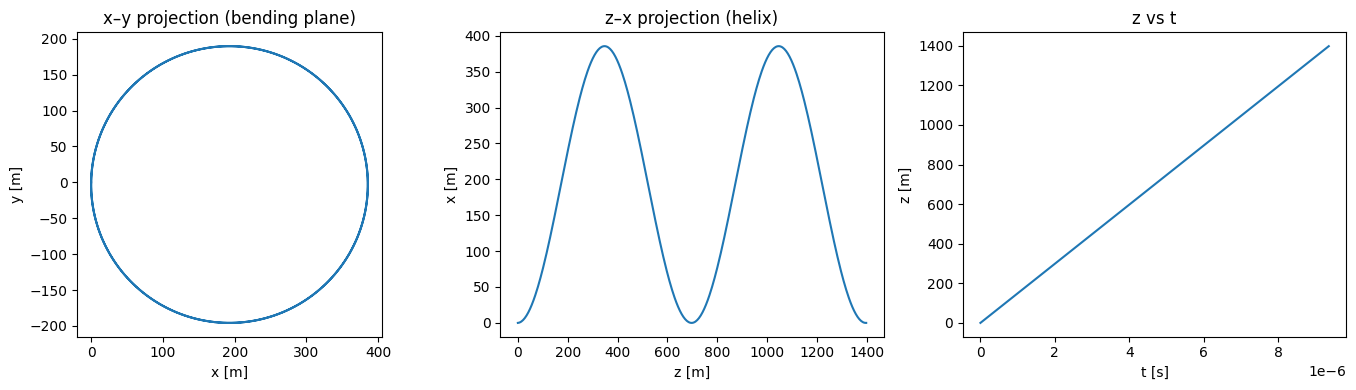

In [11]:
# --- Plotting for proton ---

fig = plt.figure(figsize=(14, 4))

ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(x_p, y_p)
ax1.set_xlabel("x [m]"); ax1.set_ylabel("y [m]")
ax1.set_aspect("equal", "box")
ax1.set_title("x–y projection (bending plane)")

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(z_p, x_p)
ax2.set_xlabel("z [m]"); ax2.set_ylabel("x [m]")
ax2.set_title("z–x projection (helix)")

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(t_p, z_p)
ax3.set_xlabel("t [s]"); ax3.set_ylabel("z [m]")
ax3.set_title("z vs t")

plt.tight_layout()
plt.show()


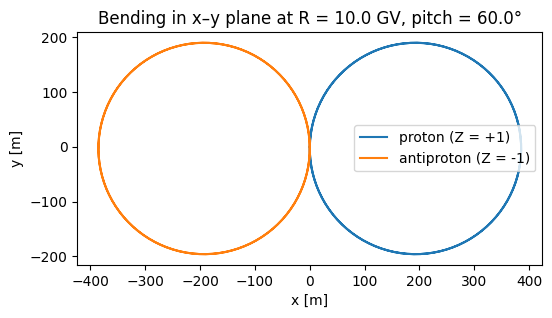

In [12]:
#--- Proton vs Antiproton Bending Comparison ---

plt.figure(figsize=(6, 6))

plt.plot(x_p, y_p, label="proton (Z = +1)")
plt.plot(x_a, y_a, label="antiproton (Z = -1)")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.gca().set_aspect("equal", "box")
plt.legend()
plt.title(f"Bending in x–y plane at R = {R_GV} GV, pitch = {pitch_angle}°")
plt.show()